1: What packages we used:

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
import re

from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [5]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

2: Data set 

In [6]:
df = pd.read_csv('all-data.csv', encoding_errors='replace', header=None, names=['label', 'text'])
df['char count'] = df['text'].str.len()
df['word count'] = df['text'].str.split().str.len()
df

,label,text,char count,word count
0,neutral,"According to Gran , the company has no plans t...",127,25
1,neutral,Technopolis plans to develop in stages an area...,190,31
2,negative,The international electronic industry company ...,228,36
3,positive,With the new production plant the company woul...,206,33
4,positive,According to the company 's updated strategy f...,203,41
...,...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,144,26
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,148,30
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,108,23
4844,negative,Net sales of the Paper segment decreased to EU...,226,44


In [5]:
# character/word counts & summary statistics (visualizations), identify outliers
# examine example texts
# frequency of words
# bigrams/trigrams
# counts per class
# Data preprocessing: tokenization, lowercasing, lemmatization, stopword removal, handling punctuation
# https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment
# Ideas for advanced project: sentiment analysis -> time series stock prediction for a specific company

Project Checkpoint 2: 

- Data cleaning, data visualizations, EDA

Spacey \+ NLTK: NLP Preprocessing 

Remove punctuation 

Standardize words / Lemmatization 

- Data cleaning code with comments for each line

- 3 distinct data visualizations: word count, key words, ?

March 10 2026: 

Tasks: 

- Project Checkpoint 2 

- Word counts/Frequency of words 

- Maybe include another data set 

- Key words 

3 Adding features

In [7]:
nltk.tokenize.word_tokenize#Nureas Test: Add word count:
#df['word count'] = df['text'].str.split().str.len()
df

,label,text,char count,word count
0,neutral,"According to Gran , the company has no plans t...",127,25
1,neutral,Technopolis plans to develop in stages an area...,190,31
2,negative,The international electronic industry company ...,228,36
3,positive,With the new production plant the company woul...,206,33
4,positive,According to the company 's updated strategy f...,203,41
...,...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,144,26
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,148,30
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,108,23
4844,negative,Net sales of the Paper segment decreased to EU...,226,44


4 Visualizations: 

Text(0.5, 0, 'Word Count')

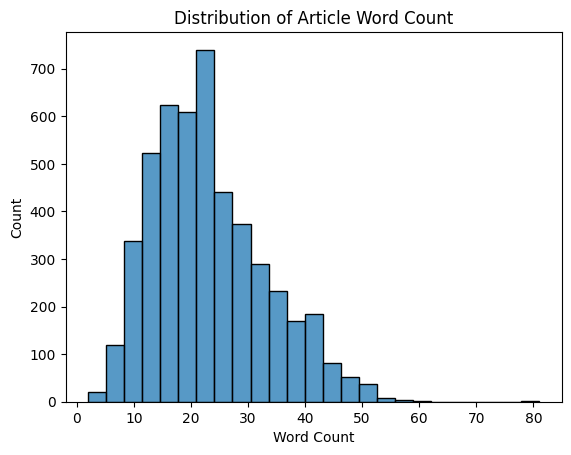

In [7]:
# Vincent: Word count histogram
sns.histplot(data=df, x='word count', stat='count', bins=25, kde=False)

plt.title('Distribution of Article Word Count')
plt.xlabel('Word Count')

<Axes: >

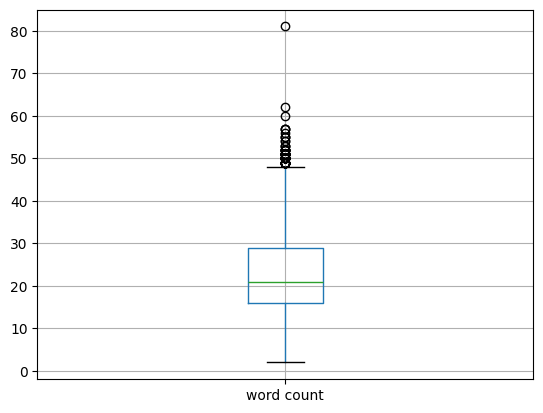

In [8]:

#Nureas Boxplot (Word count)
df.boxplot(column=['word count'])

Text(0.5, 0, 'Char Count')

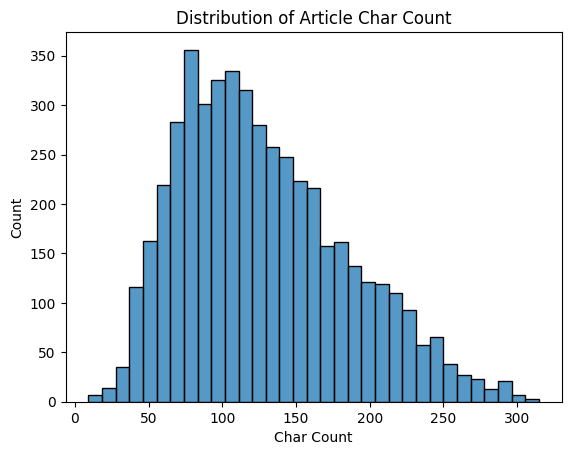

In [9]:
#Raghav Char Count 
sns.histplot(df['char count'])

plt.title('Distribution of Article Char Count')
plt.xlabel('Char Count')

<Axes: xlabel='count', ylabel='label'>

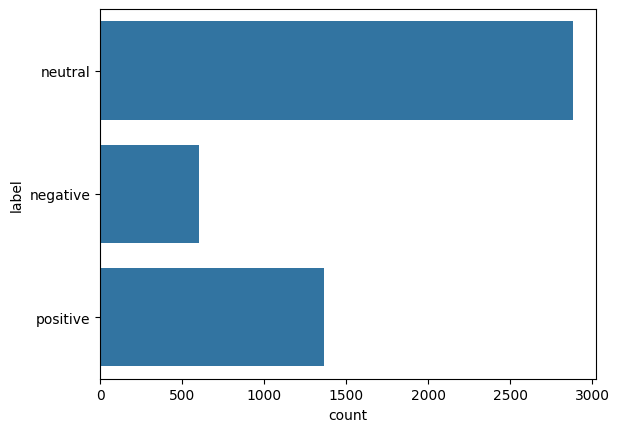

In [10]:
#Raghav Countplot 
sns.countplot(df['label'])

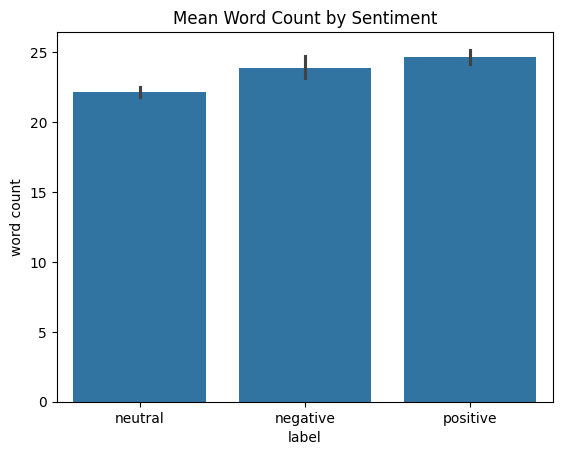

In [11]:
#nureas barplot
sns.barplot(df, x='label', y='word count')

plt.title('Mean Word Count by Sentiment')
plt.show()

5 Data Cleaning & Preprocessing

In [9]:
#brandon's Mapping Labels to Numbers: 
mapping_dict = {'positive': 1, 'neutral' : 0, 'negative' : -1}
df['label_encoded'] = df['label'].map(mapping_dict)

Preprocessing, creating functions: 

- Lowercase \(Completed\)

- Lemmatize \(Completed\)

- Remove punctuation \(Completed\) 

- Removing stop words \(Next time\)

In [11]:
#Nureas: preprocess text function
#lemmatizing basically takes a word and turns them into it's core representation: running/runs/run -> run
lem = WordNetLemmatizer()
def lemmatize(text):
    tokens = word_tokenize(text) #splits text into words 
    pos_tags = pos_tag(tokens) #Whether it's a noun/verb/etc 
    lemmas = [
        lem.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]
    return ' '.join(lemmas)


def preprocess(text):
    text = str(text).lower() #lowercase
    text = re.sub(r'[^\w\s%$]', '', text) #remove punctuation (keep % and $)
    text = lemmatize(text)
    text = text.split() #tokenize
    return ' '.join(text)

preprocess('With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .')


'with the new production plant the company would increase it capacity to meet the expected increase in demand and would improve the use of raw material and therefore increase the production profitability'

In [13]:
#Balancing
Brandon trying to do the sampling technique
#class with most examples
max_count = df['label_encoded'].value_counts().max()

# Separate by class
positive = df[df['label_encoded'] == 1]
neutral = df[df['label_encoded'] == 0]
negative = df[df['label_encoded'] == -1]

print(f"Before balancing - Positive: {len(positive)}, Neutral: {len(neutral)}, Negative: {len(negative)}")

#now do the balancing part
positive_balanced = positive.sample(n=max_count, replace=True, random_state=1)
negative_balanced = negative.sample(n=max_count, replace=True, random_state=1)

#combine and shuffle
df = pd.concat([positive_balanced, neutral, negative_balanced], ignore_index = True)
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
#output msg
print(f"After balancing - Positive: {len(df[df['label_encoded'] == 1])}, Neutral: {len(df[df['label_encoded'] == 0])}, Negative: {len(df[df['label_encoded'] == -1])}")


Before balancing - Positive: 1363, Neutral: 2879, Negative: 604
After balancing - Positive: 2879, Neutral: 2879, Negative: 2879


Next Meeting: March 17 2026 

Tasks: 

- Removing Stop words

- Test on an easy model

- Determining what our project goal 

- Taewoo needs to open the deepnote, and give us admin priveleges 

Project Goal: 

Vincent: Interested in Time Series

Brandon: Concerned about connecting things with health\. Tbh it would be hard to connect health with econ in my opinion\.

Meeting: March 17 2026

Preprocessing

Vectorization 

tf\-idf

Creating our own features from the tf\-idf vectorizer

More Preprocessing

In [15]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=20000,   # top 20k by corpus frequency
    sublinear_tf=True,    # use log(1 + tf) instead of raw tf
    min_df=2,             # ignore terms in fewer than 2 docs
    max_df=0.95           # ignore terms in more than 95% of docs
)

Example below\!: 

<img src="Screenshot 2026-03-17 at 5.24.51â¯PM.png" width="" align="" />

In [17]:
#need to improve what the right words are 
forward_looking_words = [
    # growth/expansion language
    'growing', 'growth', 'expand', 'expanding', 'expansion', 'increase',
    'increasing', 'rise', 'rising', 'improve', 'improving', 'improvement',
    'gain', 'gains', 'strengthen', 'strengthening', 'accelerate', 'surge',
    
    # explicit future intent
    'will', 'plan', 'plans', 'planned', 'planning', 'aim', 'aims', 'aiming',
    'intend', 'intends', 'target', 'targets', 'targeting', 'seek', 'seeks',
    'expect', 'expects', 'expected', 'expecting', 'forecast', 'forecasts',
    'anticipate', 'anticipates', 'project', 'projects', 'projected',
    
    # journalistic forward language
    'going forward', 'looking ahead', 'next year', 'next quarter',
    'in the coming', 'by the end of', 'hopes to', 'set to', 'poised to'
]

uncertainty_words = [
    # hedging/conditionality
    'although', 'however', 'but', 'despite', 'nevertheless', 'yet',
    'while', 'even though', 'regardless', 'notwithstanding',
    
    # attribution (journalistic uncertainty)
    'according to', 'said', 'told', 'reported', 'cited', 'claimed',
    'suggested', 'indicated', 'noted', 'added',
    
    # modal uncertainty
    'may', 'might', 'could', 'would', 'possibly', 'potentially',
    'perhaps', 'likely', 'unlikely', 'expected to',
    
    # negative forward language
    'no plans', 'not expected', 'does not expect', 'did not',
    'no guarantee', 'uncertain', 'unclear', 'remains to be seen'
]

def count_phrase_matches(text, word_list):
    text = text.lower()
    count = 0
    for phrase in word_list:
        # handles both single words and multi-word phrases
        count += len(re.findall(r'\b' + re.escape(phrase) + r'\b', text))
    return count

df['forward_looking_count'] = df['text'].apply(
    lambda x: count_phrase_matches(x, forward_looking_words)
)

df['uncertainty_count'] = df['text'].apply(
    lambda x: count_phrase_matches(x, uncertainty_words)
)

df

,label,text,char count,word count,label_encoded,forward_looking_count,uncertainty_count
0,neutral,"According to Finnish FIM Bank , Alpro 's price...",80,15,0,0,2
1,negative,"Making matters more difficult , the company sa...",180,33,-1,0,1
2,positive,CDLI highlights the companies that provided th...,134,19,1,1,0
3,negative,The SeaWind that was en route from the Finnish...,265,50,-1,0,0
4,neutral,The center offers a comprehensive range of dev...,172,27,0,0,0
...,...,...,...,...,...,...,...
8632,neutral,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,236,42,0,0,1
8633,negative,"Kiosk and cinema operations have suffered , in...",59,10,-1,0,0
8634,positive,At the same time I am delighted by the fact th...,120,24,1,0,0
8635,neutral,Nordstjernan has used its option to buy anothe...,93,18,0,0,0


In [18]:
# Text readability

X_tfidf = tfidf.fit_transform(df['text'])

df['avg_word_length'] = df['char count'] / df['word count']
df['unique_word_ratio'] = df['text'].apply(lambda x: len(set(x.split())) / len(x.split()))
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

df['stopword_ratio'] = df['text'].apply(
    lambda x: np.mean([w.lower() in ENGLISH_STOP_WORDS for w in x.split()])
)

df

,label,text,char count,word count,label_encoded,forward_looking_count,uncertainty_count,avg_word_length,unique_word_ratio,stopword_ratio
0,neutral,"According to Finnish FIM Bank , Alpro 's price...",80,15,0,0,2,5.333333,1.000000,0.266667
1,negative,"Making matters more difficult , the company sa...",180,33,-1,0,1,5.454545,0.878788,0.393939
2,positive,CDLI highlights the companies that provided th...,134,19,1,1,0,7.052632,0.894737,0.315789
3,negative,The SeaWind that was en route from the Finnish...,265,50,-1,0,0,5.300000,0.820000,0.420000
4,neutral,The center offers a comprehensive range of dev...,172,27,0,0,0,6.370370,0.814815,0.333333
...,...,...,...,...,...,...,...,...,...,...
8632,neutral,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,236,42,0,0,1,5.619048,0.809524,0.261905
8633,negative,"Kiosk and cinema operations have suffered , in...",59,10,-1,0,0,5.900000,1.000000,0.300000
8634,positive,At the same time I am delighted by the fact th...,120,24,1,0,0,5.000000,0.916667,0.625000
8635,neutral,Nordstjernan has used its option to buy anothe...,93,18,0,0,0,5.166667,1.000000,0.333333


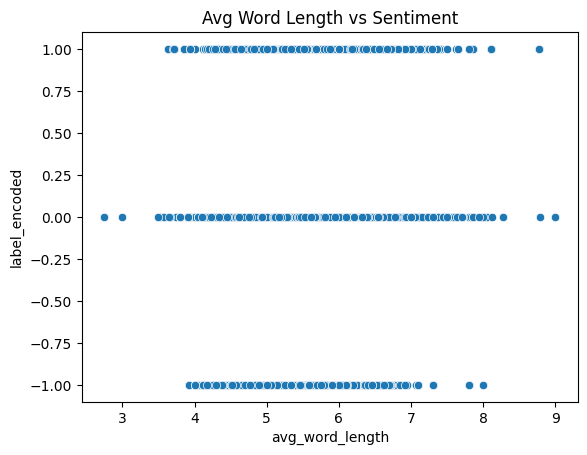

count    8637.000000
mean        5.475049
std         0.708940
min         2.750000
25%         4.958333
50%         5.444444
75%         5.926829
max         9.000000
Name: avg_word_length, dtype: float64

In [18]:
sns.scatterplot(
    x='avg_word_length',
    y='label_encoded',
    data=df
)

plt.title('Avg Word Length vs Sentiment')
plt.show()

df['avg_word_length'].describe()

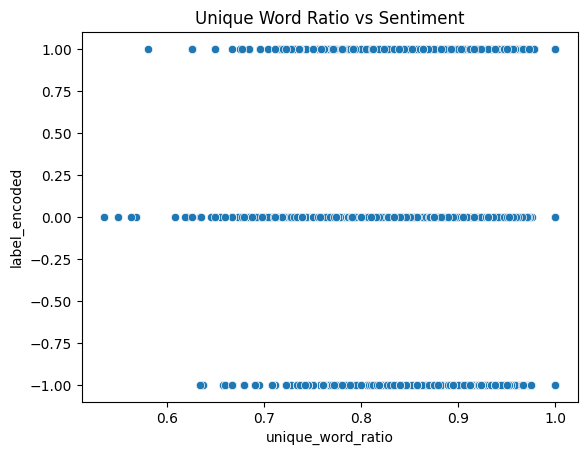

count    8637.000000
mean        0.909850
std         0.079427
min         0.534884
25%         0.857143
50%         0.920000
75%         1.000000
max         1.000000
Name: unique_word_ratio, dtype: float64

In [19]:
sns.scatterplot(
    x='unique_word_ratio',
    y='label_encoded',
    data=df
)

plt.title('Unique Word Ratio vs Sentiment')
plt.show()

df['unique_word_ratio'].describe()

In [32]:
#Adding Processed Text: 

df["processed_text"] = df['text'].apply(preprocess)
df['processed_text']



0       accord to finnish fim bank alpro s price would...
1       make matter more difficult the company say it ...
2       cdli highlight the company that provide the mo...
3       the seawind that be en route from the finnish ...
4       the center offer a comprehensive range of devi...
                              ...                        
8632    telecomworldwire7 april 2006tj group plc sell ...
8633    kiosk and cinema operation have suffer in part...
8634    at the same time i be delight by the fact that...
8635    nordstjernan have use it option to buy another...
8636    both operating profit and net sale for the thr...
Name: processed_text, Length: 8637, dtype: object

In [33]:
df

,label,text,char count,word count,label_encoded,forward_looking_count,uncertainty_count,avg_word_length,unique_word_ratio,stopword_ratio,processed_text
0,neutral,"According to Finnish FIM Bank , Alpro 's price...",80,15,0,0,2,5.333333,1.000000,0.266667,accord to finnish fim bank alpro s price would...
1,negative,"Making matters more difficult , the company sa...",180,33,-1,0,1,5.454545,0.878788,0.393939,make matter more difficult the company say it ...
2,positive,CDLI highlights the companies that provided th...,134,19,1,1,0,7.052632,0.894737,0.315789,cdli highlight the company that provide the mo...
3,negative,The SeaWind that was en route from the Finnish...,265,50,-1,0,0,5.300000,0.820000,0.420000,the seawind that be en route from the finnish ...
4,neutral,The center offers a comprehensive range of dev...,172,27,0,0,0,6.370370,0.814815,0.333333,the center offer a comprehensive range of devi...
...,...,...,...,...,...,...,...,...,...,...,...
8632,neutral,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,236,42,0,0,1,5.619048,0.809524,0.261905,telecomworldwire7 april 2006tj group plc sell ...
8633,negative,"Kiosk and cinema operations have suffered , in...",59,10,-1,0,0,5.900000,1.000000,0.300000,kiosk and cinema operation have suffer in part...
8634,positive,At the same time I am delighted by the fact th...,120,24,1,0,0,5.000000,0.916667,0.625000,at the same time i be delight by the fact that...
8635,neutral,Nordstjernan has used its option to buy anothe...,93,18,0,0,0,5.166667,1.000000,0.333333,nordstjernan have use it option to buy another...


In [34]:
#Vectorizer 

X = tfidf.fit_transform(df["processed_text"]) #making the matrix

#turning it into a pandas dataframe
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns= tfidf.get_feature_names_out()
)

tfidf_df

,00,00 mn,000,000 in,001,001 pct,002,002 eur,003,003 to,...,zinc of,zinc roaster,zinc smelter,zinclead,zinclead project,zoltan,zoltan krippl,zone,zoo,zoo in
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8632,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8633,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8634,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8635,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


label          negative  neutral  positive
length_bucket                             
Short               153      254       119
Medium             1038     1170      1035
Long               1033      894       925
Very Long           655      561       800


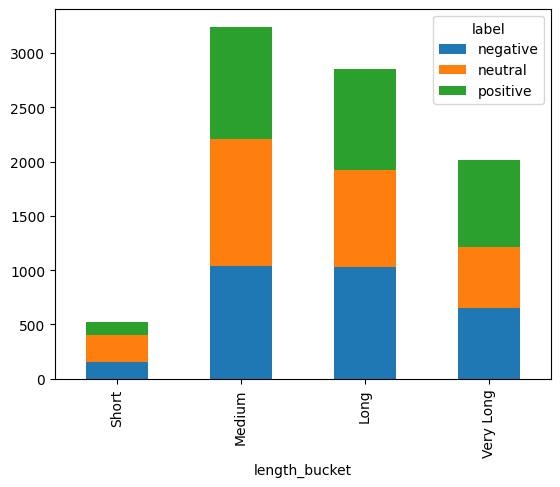

In [35]:
df['length_bucket'] = pd.cut(df['word count'], bins=[0,10,20,30,81], labels=["Short", "Medium", "Long", "Very Long"])
pivot = (df.groupby(['length_bucket', 'label'], observed=True).size().unstack('label'))

print(pivot)
pivot.plot(kind="bar", stacked=True)
plt.show()

What features did you create?

- Vincent: 'avg\_word\_length', 'unique\_word\_ratio', 'stopword\_ratio'

- Nureas: Created 'length\_bucket,' which groups each word count into 4 size categories \(Short / Medium / Long / Very Long\) to see if headline length correlates with sentiment

Plans for after break: 

Machine learning models and how they're used 

Testing different models against each other 

Splitting data into different groups: training vs testing 

<hr>

Back from Spring Break \(March 30th 2026\): 

Plans: 

- Which features are the best for our model? 

- Embeddings

- Train different models: Logistic regression, decision trees, pre\-training 

<hr>

In [37]:
df


,label,text,char count,word count,label_encoded,forward_looking_count,uncertainty_count,avg_word_length,unique_word_ratio,stopword_ratio,processed_text,length_bucket
0,neutral,"According to Finnish FIM Bank , Alpro 's price...",80,15,0,0,2,5.333333,1.000000,0.266667,accord to finnish fim bank alpro s price would...,Medium
1,negative,"Making matters more difficult , the company sa...",180,33,-1,0,1,5.454545,0.878788,0.393939,make matter more difficult the company say it ...,Very Long
2,positive,CDLI highlights the companies that provided th...,134,19,1,1,0,7.052632,0.894737,0.315789,cdli highlight the company that provide the mo...,Medium
3,negative,The SeaWind that was en route from the Finnish...,265,50,-1,0,0,5.300000,0.820000,0.420000,the seawind that be en route from the finnish ...,Very Long
4,neutral,The center offers a comprehensive range of dev...,172,27,0,0,0,6.370370,0.814815,0.333333,the center offer a comprehensive range of devi...,Long
...,...,...,...,...,...,...,...,...,...,...,...,...
8632,neutral,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,236,42,0,0,1,5.619048,0.809524,0.261905,telecomworldwire7 april 2006tj group plc sell ...,Very Long
8633,negative,"Kiosk and cinema operations have suffered , in...",59,10,-1,0,0,5.900000,1.000000,0.300000,kiosk and cinema operation have suffer in part...,Short
8634,positive,At the same time I am delighted by the fact th...,120,24,1,0,0,5.000000,0.916667,0.625000,at the same time i be delight by the fact that...,Long
8635,neutral,Nordstjernan has used its option to buy anothe...,93,18,0,0,0,5.166667,1.000000,0.333333,nordstjernan have use it option to buy another...,Medium


<hr>

7 Models:

Logistic Regression: 

Steps: 

Import training test split

helpful link\(s\): 

1\. https://scikit\-learn\.org/stable/modules/generated/sklearn\.model\_selection\.train\_test\_split\.html

2\. https://scikit\-learn\.org/stable/modules/generated/sklearn\.linear\_model\.LogisticRegression\.html

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = tfidf_df
y = df['label_encoded']

# split our data into train and test sets 80/20
# feed our training data to our model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=1)


In [41]:
#Creating the model 
model = LogisticRegression() 
model.fit(X_train, y_train)

KeyboardInterrupt: 

Current issues: imbalanced dataset (more neutral labels currently), model accuracy not performing well on negative/positively labeled data

In [38]:
#logistic regression
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.95      0.98      0.97       592
           0       0.91      0.88      0.89       579
           1       0.90      0.91      0.90       557

    accuracy                           0.92      1728
   macro avg       0.92      0.92      0.92      1728
weighted avg       0.92      0.92      0.92      1728



What is precision, recall, and f1\-score? 

<img src="Screenshot 2026-03-30 at 6.37.40â¯PM.png" width="50" align="" />

<img src="Screenshot 2026-03-30 at 6.38.22â¯PM.png" width="50" align="" />

<img src="Screenshot 2026-03-30 at 6.39.31â¯PM.png" width="75" align="" />

Models:

- Logistic Regression 

- Neural Network\(Brandon\) 

- https://scikit\-learn\.org/stable/modules/neural\_networks\_supervised\.html

- Naive Bayes \(Raghav\) Completed

- https://scikit\-learn\.org/stable/modules/generated/sklearn\.naive\_bayes\.MultinomialNB\.html

- Random forest \+ XGBoost \(Vincent\)

- https://scikit\-learn\.org/stable/modules/generated/sklearn\.ensemble\.RandomForestClassifier\.html

- https://xgboost\.readthedocs\.io/en/stable/tutorials/rf\.html

- tutorial: https://machinelearningmastery\.com/random\-forest\-ensembles\-with\-xgboost/

- SVM Completed

- https://scikit\-learn\.org/stable/modules/svm\.html

- Will need to choose with SVC to use\! \-\-\> can scale data and use Linear SVC

- FinBERT

- https://huggingface\.co/ProsusAI/finbert

Optimizations:

- Oversampling of minority classes \(maybe SMOTE\)

- SMOTE may create new data that does not make sense to our context, could either sample more/less of certain classes

- Resource: https://scikit\-learn\.org/stable/modules/generated/sklearn\.utils\.resample\.html

- Work with label and text in original data frame

- Tuning hyperparameters \(ngrams, max\_features, etc\.\)

- Cross\-validation vs simple train\-test split

April 7th 2026: \(Testing new models\) 

In [28]:
#testing Naive Bayes 

from sklearn.naive_bayes import MultinomialNB

model_Bayes = MultinomialNB(alpha=1.0)
model_Bayes.fit(X_train, y_train)
y_pred_Bayes = model_Bayes.predict(X_test)

print(classification_report(y_test,y_pred_Bayes))

              precision    recall  f1-score   support

          -1       0.89      0.95      0.92       592
           0       0.78      0.90      0.84       579
           1       0.92      0.72      0.81       557

    accuracy                           0.86      1728
   macro avg       0.87      0.86      0.86      1728
weighted avg       0.87      0.86      0.86      1728



In [45]:
!pip install xgboost==3.2.0


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

X_reduced = tfidf_df
y = df['label_encoded']

print("Data shapes:")
print(f"  X shape: {X_reduced.shape}")
print(f"  y shape: {y.shape}")

unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Label {label}: {count} samples")
print()

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    max_features=50,
    random_state=42,
    n_jobs=1,
    verbose=0
)

scores = cross_val_score(
    model,
    X_reduced,
    y,
    cv=cv,
    scoring='f1_macro',
    n_jobs=1
)

print("CROSS-VALIDATION RESULTS")
print(f"Mean F1 Score: {np.mean(scores):.4f}")
print(f"Std Dev: {np.std(scores):.4f}")
print(f"Min/Max: {np.min(scores):.4f} / {np.max(scores):.4f}")

final_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    max_features=50,
    random_state=42,
    n_jobs=1
)
final_model.fit(X_reduced, y)

Data shapes:
  X shape: (8637, 20000)
  y shape: (8637,)
  Label -1: 2879 samples
  Label 0: 2879 samples
  Label 1: 2879 samples

CROSS-VALIDATION RESULTS
Mean F1 Score: 0.4864
Std Dev: 0.0324
Min/Max: 0.4465 / 0.5260


RandomForestClassifier(max_depth=5, max_features=50, n_estimators=10, n_jobs=1,
                       random_state=42)

In [99]:
#Linear SVM
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

model = LinearSVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
Accuracy: 0.8010309278350516
              precision    recall  f1-score   support

          -1       0.86      0.57      0.68       122
           0       0.79      0.92      0.85       570
           1       0.80      0.65      0.72       278

    accuracy                           0.80       970
   macro avg       0.82      0.71      0.75       970
weighted avg       0.80      0.80      0.79       970



In [51]:
#also testing neural network

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Accuracy: 0.9334490740740741
              precision    recall  f1-score   support

          -1       0.97      0.99      0.98       592
           0       0.91      0.90      0.91       579
           1       0.92      0.90      0.91       557

    accuracy                           0.93      1728
   macro avg       0.93      0.93      0.93      1728
weighted avg       0.93      0.93      0.93      1728



In [66]:
#neural network with pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, accuracy_score

#just in case
X_train_dense = X_train.values
X_test_dense = X_test.values

X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_dense, dtype=torch.float32)
#doesnt negative index
y_train_mapped = y_train + 1
y_test_mapped = y_test + 1

y_train_tensor = torch.tensor(y_train_mapped.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_mapped.values, dtype=torch.long)

#neural network architecture
class TextClassifierMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(TextClassifierMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.relu(out)
        out = self.layer2(out)
        return out

# initialize 
input_dim = X_train_tensor.shape[1] 
model = TextClassifierMLP(input_size=input_dim, hidden_size=100, num_classes=3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


epochs = 150

for epoch in range(epochs):
    model.train()
    
    outputs = model(X_train_tensor)
    
    loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


# Set model to eval mode
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, predicted = torch.max(test_outputs.data, 1)
    predicted_labels = predicted.numpy() - 1

# Print
print("Accuracy:", accuracy_score(y_test, predicted_labels))
print(classification_report(y_test, predicted_labels))

NameError: name 'X_train' is not defined

Summary: Tested different models\. 

Next Meeting: Figuring out the presentation\. 

April 14th 2026 Presentation:

What is our project and domain? Outline\. \- Raghav

What data set did we use? 

How did we clean/preprocessing the data?  

Visualizations/EDA 

How did we encode/normalize? 

What models did we use? 

What machine learning models did we use?

Summary/Conclusion \- 